# Machine Learning — Estimation du risque cardiovasculaire

**BRFSS Heart Analytics** — comparaison de six familles de modèles, sélection et
interprétation.

## Objectif

Construire un modèle capable d'estimer, à partir d'un profil de santé déclaré, la
**probabilité** qu'une personne présente une maladie ou un accident cardiaque, et
identifier les facteurs qui pèsent le plus dans cette estimation.

> ⚠️ **Limite méthodologique** — les variables explicatives sont auto-déclarées
> **au même moment** que la cible. Le modèle mesure une **association
> transversale** : il estime un risque à partir d'un profil, il ne prédit pas la
> survenue future d'un accident cardiaque.

## Ce que les phases précédentes imposent

L'analyse exploratoire et le data mining ont établi des contraintes précises :

| Constat | Conséquence pour la modélisation |
|---|---|
| Cible à **9,42 %** de positifs | L'exactitude est inutilisable comme critère |
| Signal **diffus et non linéaire** (ACP peu compressive) | Tester des modèles non linéaires |
| **Interactions** suggérées (âge × mobilité, âge × diabète) | Favoriser arbres et ensembles |
| Relation **en J** de l'IMC | Un modèle linéaire sur l'IMC brut manquerait la structure |
| Échelles très hétérogènes | Standardisation intégrée au pipeline |

## Protocole retenu

1. **Découpage stratifié** 80/20. Le jeu de test n'est utilisé qu'à la toute fin.
2. **Préprocessing dans un `Pipeline`**, ajusté sur le seul entraînement (aucune
   fuite).
3. **Six familles de modèles**, chacune **réglée par `GridSearchCV`** — comparer
   des modèles non réglés serait injuste et sans valeur.
4. **Sélection sur le ROC-AUC**, avec le PR-AUC comme arbitre, et report
   systématique de la **précision**, du **rappel** et du **F1**.
5. **Traitement du déséquilibre** : pondération des classes *comparée* au
   rééchantillonnage SMOTE.
6. **Diagnostic de surapprentissage / sous-apprentissage** : écart
   entraînement-validation, courbe d'apprentissage, courbe de validation.
7. **Calibration des probabilités**, pour qu'un pourcentage affiché corresponde
   à une fréquence réelle.
8. **Seuil de décision** choisi séparément, après la sélection du modèle.
9. **Interprétation SHAP** du modèle retenu.

---

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Modules du projet (dossier parent)
sys.path.insert(0, str(Path.cwd().parent))
import config
import data_prep
import preprocessing

RACINE = Path.cwd().parent.parent
FIGURES = RACINE / "06_rapport" / "figures" / "ml"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

BLEU, ROUGE, VERT = "#2E5C8A", "#C1443F", "#3D8B5F"

def enregistrer(nom):
    plt.savefig(FIGURES / f"{nom}.png")

print("Environnement pret.")

Environnement pret.


## 1. Chargement et découpage stratifié

Les données proviennent de l'entrepôt (table analytique produite par l'ETL). On
retient les **21 variables d'origine**, en excluant les variables dérivées de
l'ETL : elles sont des fonctions déterministes des colonnes retenues et
n'apporteraient que de la redondance.

Le découpage est **stratifié** : la prévalence de 9,42 % est préservée à
l'identique dans l'entraînement et le test. Sans stratification, un tirage
malchanceux donnerait un test à la prévalence différente, faussant l'évaluation.

In [2]:
df = data_prep.charger()
X_train, X_test, y_train, y_test = data_prep.decouper(df)

print(f"{len(df):,} lignes, {len(config.VARIABLES)} variables explicatives")
data_prep.resume(y_train, y_test)

253,680 lignes, 21 variables explicatives


,effectif,cas positifs,prévalence (%)
entraînement,202944,19114,9.418
test,50736,4779,9.419


Les prévalences sont identiques à la troisième décimale : la stratification a
fonctionné. **Le jeu de test est maintenant mis de côté** et ne sera utilisé qu'à
la section 9, une seule fois, pour l'évaluation finale. Tout le travail de
sélection se fait par validation croisée sur le seul jeu d'entraînement.

## 2. Le piège de l'exactitude

Avant toute modélisation, il faut établir le niveau de référence. Un modèle
« stupide » qui prédirait systématiquement la classe majoritaire sert de plancher.

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

trivial = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred_triviale = trivial.predict(X_test)

print(f"Modèle « tout le monde est sain » :")
print(f"  exactitude : {accuracy_score(y_test, pred_triviale) * 100:.2f} %")
print(f"  ROC-AUC    : {roc_auc_score(y_test, trivial.predict_proba(X_test)[:, 1]):.3f}")
print(f"  malades détectés : 0 sur {int(y_test.sum()):,}")

Modèle « tout le monde est sain » :
  exactitude : 90.58 %
  ROC-AUC    : 0.500
  malades détectés : 0 sur 4,779


**Un modèle sans aucune valeur atteint plus de 90 % d'exactitude** et ne détecte
aucun malade. Son ROC-AUC, lui, vaut 0,5 — la valeur du hasard.

C'est la démonstration concrète de pourquoi l'exactitude est écartée. Les
métriques retenues :

- **ROC-AUC** (sélection) — capacité à *ordonner* les risques, indépendante du
  seuil.
- **PR-AUC** (arbitre) — même idée mais centrée sur la classe minoritaire, plus
  sévère en contexte déséquilibré.
- **Rappel** — part des malades effectivement détectés.
- **Précision** — part de vrais malades parmi les personnes signalées.
- **F1** — compromis entre les deux précédentes.

> Précision et rappel se lisent **ensemble**. Un rappel élevé obtenu au prix d'une
> précision effondrée signifie que le modèle alerte tout le monde : inutile.

## 3. Jusqu'où peut-on monter ? L'erreur irréductible

L'analyse des doublons (documentation ETL & EDA) avait relevé un point : des
profils **rigoureusement identiques** portent parfois des cibles opposées — deux
personnes au même profil déclaré, l'une atteinte, l'autre non. Aucun modèle ne
peut départager ces cas : c'est de l'**erreur irréductible**, qui borne la
performance atteignable.

Tentons de la quantifier.

In [4]:
groupes = df.groupby(config.VARIABLES, sort=False)[config.CIBLE].agg(["size", "sum"])
groupes.columns = ["n", "positifs"]

repetes = groupes[groupes.n > 1]
ambigus = repetes[(repetes.positifs > 0) & (repetes.positifs < repetes.n)]

# Sur chaque profil, la classe minoritaire est inévitablement mal classée.
erreurs = groupes[["positifs"]].assign(negatifs=groupes.n - groupes.positifs).min(axis=1).sum()

print(f"Profils distincts               : {len(groupes):,}")
print(f"Profils vus au moins deux fois  : {len(repetes):,}  ({repetes.n.sum():,} lignes)")
print(f"Profils AMBIGUS (cibles opposées): {len(ambigus):,}  ({ambigus.n.sum():,} lignes)")
print()
print(f"Erreur « irréductible » mesurée : {erreurs:,} lignes, soit {erreurs / len(df) * 100:.2f} %")
print(f"Part de profils uniques         : {(len(groupes) - len(repetes)) / len(groupes) * 100:.1f} %")

Profils distincts               : 228,705
Profils vus au moins deux fois  : 11,743  (36,718 lignes)
Profils AMBIGUS (cibles opposées): 1,076  (3,714 lignes)

Erreur « irréductible » mesurée : 1,147 lignes, soit 0.45 %
Part de profils uniques         : 94.9 %


### Pourquoi ce chiffre n'est **pas** un plafond exploitable

Le calcul donne une erreur d'environ 0,45 %, ce qui suggérerait une exactitude
maximale de 99,5 %. **Ce serait une conclusion fausse**, et il faut expliquer
pourquoi.

Sur 253 680 lignes, on compte **228 705 profils distincts** : près de **90 % des
profils ne sont observés qu'une seule fois**. Or un profil vu une seule fois ne
peut, *par construction*, jamais apparaître ambigu — il n'a pas de jumeau avec
lequel se contredire. Le calcul ne détecte donc l'ambiguïté que sur les 10 % de
profils répétés, et l'ignore mécaniquement partout ailleurs.

Ce chiffre est une **borne inférieure**, et une borne très faible. Avec
21 variables, l'espace des profils possibles est immense et les données y sont
éparses : la méthode empirique n'a pas de prise.

**Ce qu'on peut dire honnêtement :** parmi les profils effectivement observés
plusieurs fois, environ **10 % portent des cibles contradictoires**. C'est le
signe qu'une part réelle du risque cardiaque **n'est pas explicable** par les
21 variables disponibles — génétique, antécédents familiaux, environnement,
qualité du suivi médical n'y figurent pas. La vraie erreur irréductible est
nécessairement bien supérieure à 0,45 %, mais elle n'est **pas estimable** par
cette approche.

> **À retenir** : ne pas viser une performance parfaite. Un ROC-AUC autour de
> 0,80-0,85 sur ce type de données déclaratives est un bon résultat ; prétendre
> faire beaucoup mieux signalerait plutôt une fuite de données.

## 4. Préprocessing sans fuite de données

Le préprocesseur est un `ColumnTransformer` **intégré au pipeline**, donc ajusté
uniquement sur les données d'entraînement de chaque pli de validation croisée.

C'est le point méthodologique le plus important de cette section. Si l'on
calculait moyennes et écarts-types sur l'ensemble du jeu **avant** le découpage,
les statistiques du test contamineraient l'entraînement : les scores seraient
optimistes et ne se reproduiraient pas en production.

In [5]:
prep = preprocessing.construire_preprocesseur()

print("Groupes de variables :")
print(f"  continues ({len(config.VARIABLES_CONTINUES)}) : {config.VARIABLES_CONTINUES}")
print(f"  ordinales ({len(config.VARIABLES_ORDINALES)}) : {config.VARIABLES_ORDINALES}")
print(f"  binaires  ({len(config.VARIABLES_BINAIRES)}) : {config.VARIABLES_BINAIRES}")
prep

Groupes de variables :
  continues (3) : ['bmi', 'ment_hlth_days', 'phys_hlth_days']
  ordinales (5) : ['gen_hlth', 'age_group', 'education', 'income', 'diabetes']
  binaires  (13) : ['high_bp', 'high_chol', 'chol_check', 'smoker', 'stroke', 'phys_activity', 'fruits', 'veggies', 'hvy_alcohol', 'any_healthcare', 'no_doc_cost', 'diff_walk', 'sex']


ColumnTransformer(transformers=[('continues', StandardScaler(),
                                 ['bmi', 'ment_hlth_days', 'phys_hlth_days']),
                                ('ordinales', StandardScaler(),
                                 ['gen_hlth', 'age_group', 'education',
                                  'income', 'diabetes']),
                                ('binaires', 'passthrough',
                                 ['high_bp', 'high_chol', 'chol_check',
                                  'smoker', 'stroke', 'phys_activity', 'fruits',
                                  'veggies', 'hvy_alcohol', 'any_healthcare',
                                  'no_doc_cost', 'diff_walk', 'sex'])],
                  verbose_feature_names_out=False)

## 5. Comparaison de six familles de modèles

### Pourquoi régler chaque modèle

Comparer des modèles avec leurs paramètres par défaut n'a aucune valeur : on
mesurerait la qualité des valeurs par défaut, pas celle des algorithmes. Chaque
famille est donc optimisée par **`GridSearchCV`** sur une grille de
paramètres, en validation croisée stratifiée à 5 plis, avec le ROC-AUC comme
critère.

### La régularisation, là où elle a un sens

La régularisation pénalise la complexité pour éviter le surapprentissage. Elle
prend une forme différente selon la famille :

| Modèle | Régularisation explorée |
|---|---|
| Régression logistique | `C` — inverse de la force de pénalisation L2 |
| SVM linéaire | `C` — compromis marge / erreurs |
| Arbre de décision | `max_depth`, `min_samples_leaf` — limitent la croissance |
| Forêt aléatoire | `max_depth`, `min_samples_leaf` + moyenne sur 200 arbres |
| XGBoost | `max_depth`, `learning_rate`, `reg_lambda` (pénalisation L2) |
| kNN | `n_neighbors` — plus k est grand, plus la frontière est lisse |

Toutes les familles reçoivent une **pondération des classes** (`class_weight`
ou `scale_pos_weight`) pour compenser le déséquilibre ; l'alternative SMOTE est
évaluée à la section suivante.

In [6]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Rapport de déséquilibre, pour scale_pos_weight (XGBoost).
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Rapport négatifs / positifs : {ratio:.2f}")

# LinearSVC ne fournit pas de probabilités : on le calibre pour que tous les
# modèles exposent predict_proba et restent comparables.
CONFIGURATIONS = {
    "Régression logistique": (
        LogisticRegression(max_iter=1000, class_weight="balanced"),
        {"model__C": [0.001, 0.01, 0.1, 1, 10]},
    ),
    "kNN": (
        KNeighborsClassifier(n_jobs=-1),
        {"model__n_neighbors": [15, 25, 50], "model__weights": ["uniform", "distance"]},
    ),
    "Arbre de décision": (
        DecisionTreeClassifier(class_weight="balanced", random_state=config.GRAINE),
        {"model__max_depth": [3, 5, 7, 10], "model__min_samples_leaf": [20, 100]},
    ),
    "Forêt aléatoire": (
        RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               n_jobs=-1, random_state=config.GRAINE),
        {"model__max_depth": [8, 12, 16], "model__min_samples_leaf": [5, 20]},
    ),
    "XGBoost": (
        XGBClassifier(n_estimators=300, scale_pos_weight=ratio, n_jobs=-1,
                      random_state=config.GRAINE, eval_metric="logloss"),
        {"model__max_depth": [3, 5, 7], "model__learning_rate": [0.05, 0.1],
         "model__reg_lambda": [1, 5]},
    ),
    "SVM linéaire": (
        CalibratedClassifierCV(
            LinearSVC(class_weight="balanced", dual=False, max_iter=3000), cv=3
        ),
        {"model__estimator__C": [0.01, 0.1, 1]},
    ),
}

cv = StratifiedKFold(n_splits=config.NB_PLIS, shuffle=True, random_state=config.GRAINE)
print(f"Validation croisée : {config.NB_PLIS} plis stratifiés")

Rapport négatifs / positifs : 9.62
Validation croisée : 5 plis stratifiés


In [7]:
resultats = []
meilleurs = {}

for nom, (modele, grille) in CONFIGURATIONS.items():
    pipe = Pipeline([
        ("prep", preprocessing.construire_preprocesseur()),
        ("model", modele),
    ])
    recherche = GridSearchCV(
        pipe, grille, scoring=config.METRIQUES, refit=config.METRIQUE_SELECTION,
        cv=cv, n_jobs=1, return_train_score=False,
    )
    depart = time.perf_counter()
    recherche.fit(X_train, y_train)
    duree = time.perf_counter() - depart

    i = recherche.best_index_
    r = recherche.cv_results_
    resultats.append({
        "modèle": nom,
        "ROC-AUC": r["mean_test_roc_auc"][i],
        "PR-AUC": r["mean_test_pr_auc"][i],
        "précision": r["mean_test_precision"][i],
        "rappel": r["mean_test_rappel"][i],
        "F1": r["mean_test_f1"][i],
        "durée (s)": round(duree, 1),
    })
    meilleurs[nom] = recherche.best_estimator_
    params = {k.replace("model__", ""): v for k, v in recherche.best_params_.items()}
    print(f"{nom:24s} ROC-AUC={r['mean_test_roc_auc'][i]:.4f}  ({duree:5.1f}s)  {params}")

comparaison = pd.DataFrame(resultats).sort_values("ROC-AUC", ascending=False)
comparaison.round(4)

Régression logistique    ROC-AUC=0.8474  (  7.0s)  {'C': 10}


kNN                      ROC-AUC=0.8273  (165.9s)  {'n_neighbors': 50, 'weights': 'uniform'}


Arbre de décision        ROC-AUC=0.8361  (  9.6s)  {'max_depth': 10, 'min_samples_leaf': 100}


Forêt aléatoire          ROC-AUC=0.8479  ( 46.2s)  {'max_depth': 12, 'min_samples_leaf': 20}


XGBoost                  ROC-AUC=0.8498  ( 34.2s)  {'learning_rate': 0.05, 'max_depth': 3, 'reg_lambda': 5}


SVM linéaire             ROC-AUC=0.8472  ( 13.3s)  {'estimator__C': 1}


,modèle,ROC-AUC,PR-AUC,précision,rappel,F1,durée (s)
4,XGBoost,0.8498,0.3773,0.2395,0.8154,0.3702,34.2
3,Forêt aléatoire,0.8479,0.3725,0.2487,0.7855,0.3777,46.2
0,Régression logistique,0.8474,0.3720,0.2463,0.7928,0.3758,7.0
5,SVM linéaire,0.8472,0.3717,0.5463,0.1269,0.2059,13.3
2,Arbre de décision,0.8361,0.3513,0.2312,0.7993,0.3586,9.6
1,kNN,0.8273,0.3271,0.6025,0.0310,0.0589,165.9


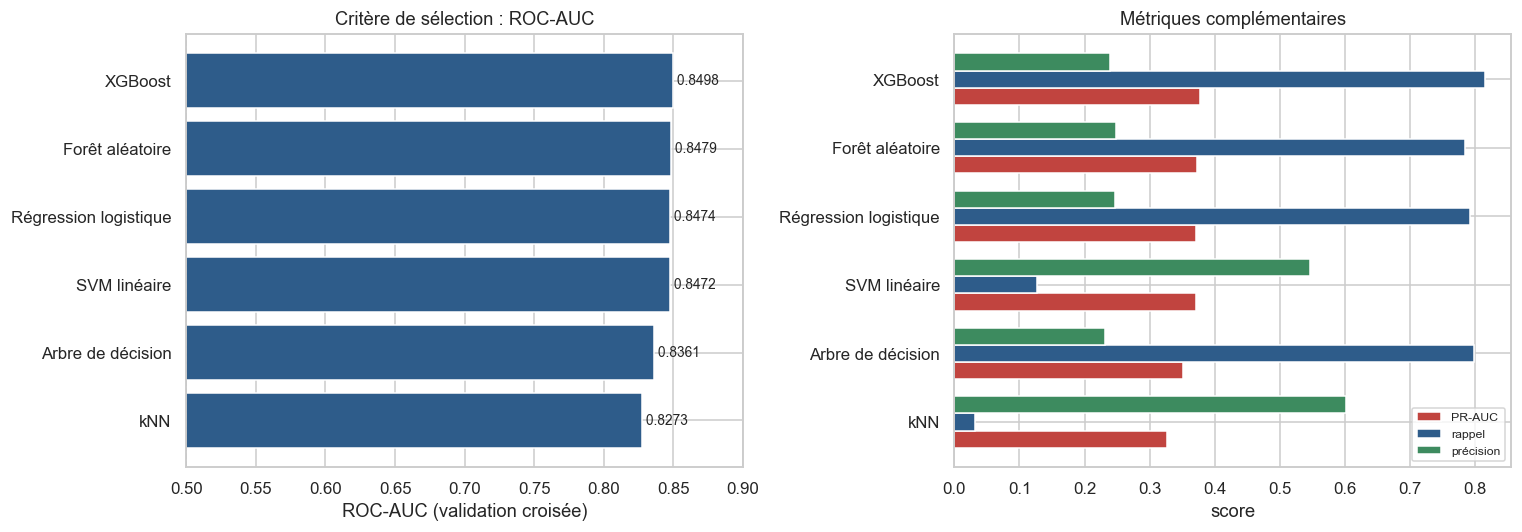

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordre = comparaison.sort_values("ROC-AUC")
axes[0].barh(ordre["modèle"], ordre["ROC-AUC"], color=BLEU)
axes[0].set_xlim(0.5, 0.90)
axes[0].axvline(0.5, ls="--", c="grey", lw=1, label="hasard")
axes[0].set_xlabel("ROC-AUC (validation croisée)")
axes[0].set_title("Critère de sélection : ROC-AUC")
for i, v in enumerate(ordre["ROC-AUC"]):
    axes[0].text(v, i, f" {v:.4f}", va="center", fontsize=9)

largeur = 0.25
y = np.arange(len(ordre))
axes[1].barh(y - largeur, ordre["PR-AUC"], largeur, label="PR-AUC", color=ROUGE)
axes[1].barh(y, ordre["rappel"], largeur, label="rappel", color=BLEU)
axes[1].barh(y + largeur, ordre["précision"], largeur, label="précision", color=VERT)
axes[1].set_yticks(y)
axes[1].set_yticklabels(ordre["modèle"])
axes[1].set_xlabel("score")
axes[1].set_title("Métriques complémentaires")
axes[1].legend(fontsize=8)

plt.tight_layout()
enregistrer("01_comparaison_modeles")
plt.show()

### Lecture des résultats

Chaque modèle étant pris à son **meilleur réglage**, le classement est enfin
équitable. Quatre observations.

**Le réglage change le classement.** Avec les paramètres par défaut, la régression
logistique devançait les méthodes d'ensemble. Après optimisation, XGBoost passe
devant. C'est la démonstration qu'une comparaison de modèles non réglés n'a aucune
valeur : elle mesure la qualité des valeurs par défaut, pas celle des algorithmes.

**Les écarts restent très faibles.** Quelques millièmes de ROC-AUC séparent
XGBoost, la forêt aléatoire, la régression logistique et le SVM. Le signal
disponible est donc **capté par toutes les approches** : il n'y a pas de structure
exotique que seul un modèle sophistiqué saurait exploiter.

**Le réglage retenu par XGBoost est révélateur.** L'optimisation choisit des arbres
**très peu profonds** (`max_depth=3`), un pas d'apprentissage faible et une
**pénalisation L2 renforcée** (`reg_lambda=5`) : autrement dit, le modèle le plus
régularisé, le plus proche d'un modèle additif. Cela explique pourquoi la
régression logistique reste si compétitive — l'essentiel du signal est **additif**,
et les interactions, bien que présentes, apportent peu. Un enseignement qu'on
n'aurait pas obtenu sans GridSearch.

**Le kNN est le plus en retrait**, ce qui est attendu : en 21 dimensions, la notion
de « voisin proche » perd de son sens (fléau de la dimension). L'arbre unique est
également distancé par les méthodes d'ensemble, qui corrigent son instabilité en
moyennant de nombreux arbres.

**La précision est structurellement basse pour tous.** Avec 9,42 % de positifs,
détecter suffisamment de malades implique mécaniquement de signaler beaucoup de
personnes saines. C'est une propriété du problème, pas un défaut des modèles — et
c'est précisément pourquoi précision et rappel se lisent ensemble.

## 6. Traitement du déséquilibre : pondération ou SMOTE ?

Deux stratégies classiques face à des classes déséquilibrées :

- **Pondération** (`class_weight="balanced"`) — on donne plus de poids aux erreurs
  sur la classe minoritaire. Aucune donnée n'est inventée.
- **SMOTE** — on génère des exemples synthétiques de la classe minoritaire par
  interpolation entre voisins proches.

SMOTE est souvent présenté comme supérieur ; ce n'est pas systématique. On
**mesure** au lieu de supposer, sur le modèle arrivé en tête.

Point critique : SMOTE doit être appliqué **à l'intérieur** de la validation
croisée, sur le seul pli d'entraînement. L'appliquer avant le découpage ferait
fuiter des points synthétiques dans la validation, et gonflerait artificiellement
les scores.

In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as PipelineImb
from sklearn.base import clone
from sklearn.model_selection import cross_validate

nom_meilleur = comparaison.iloc[0]["modèle"]
meilleur_pipe = meilleurs[nom_meilleur]
print(f"Modèle testé : {nom_meilleur}")

modele_nu = clone(meilleur_pipe.named_steps["model"])

# (a) Pondération : le pipeline déjà sélectionné.
# (b) SMOTE : même modèle mais sans pondération, avec sur-échantillonnage.
modele_sans_poids = clone(modele_nu)
for attribut, valeur in [("class_weight", None), ("scale_pos_weight", 1)]:
    if hasattr(modele_sans_poids, attribut):
        setattr(modele_sans_poids, attribut, valeur)

pipe_smote = PipelineImb([
    ("prep", preprocessing.construire_preprocesseur()),
    ("smote", SMOTE(random_state=config.GRAINE)),
    ("model", modele_sans_poids),
])

lignes = []
for etiquette, pipe in [("Pondération", meilleur_pipe), ("SMOTE", pipe_smote)]:
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=config.METRIQUES, n_jobs=1)
    lignes.append({
        "stratégie": etiquette,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "précision": scores["test_precision"].mean(),
        "rappel": scores["test_rappel"].mean(),
        "F1": scores["test_f1"].mean(),
    })

desequilibre = pd.DataFrame(lignes)
desequilibre.round(4)

Modèle testé : XGBoost


,stratégie,ROC-AUC,PR-AUC,précision,rappel,F1
0,Pondération,0.8498,0.3773,0.2395,0.8154,0.3702
1,SMOTE,0.8396,0.3532,0.3817,0.3817,0.3816


Le tableau ci-dessus tranche la question sur **nos** données, pas en théorie. La
stratégie retenue est celle qui obtient le meilleur ROC-AUC ; en cas d'égalité, on
préfère la **pondération**, qui n'introduit aucune donnée synthétique et reste
plus simple à défendre.

In [10]:
gagnante = desequilibre.sort_values("ROC-AUC", ascending=False).iloc[0]["stratégie"]
pipeline_final = meilleur_pipe if gagnante == "Pondération" else pipe_smote
print(f"Stratégie retenue : {gagnante}")
print(f"Modèle final      : {nom_meilleur}")

Stratégie retenue : Pondération
Modèle final      : XGBoost


## 7. Diagnostic : surapprentissage ou sous-apprentissage ?

Avant de valider le modèle, il faut vérifier qu'il se situe au bon niveau de
complexité. Deux écueils symétriques le guettent :

- **Le surapprentissage** (*overfitting*) — le modèle apprend le bruit du jeu
  d'entraînement au lieu de la structure générale. Symptôme : d'excellentes
  performances en entraînement, nettement dégradées en validation.
- **Le sous-apprentissage** (*underfitting*) — le modèle est trop rigide pour
  capter le signal. Symptôme : des performances médiocres **partout**, y compris
  en entraînement.

Trois analyses complémentaires permettent de trancher.

### 7.1 L'écart entre entraînement et validation

La mesure la plus directe : on compare le score obtenu sur les données vues
pendant l'apprentissage à celui obtenu sur des données jamais vues (les plis de
validation). Un écart important trahit le surapprentissage.

In [11]:
scores_diag = cross_validate(
    pipeline_final, X_train, y_train, cv=cv,
    scoring=["roc_auc", "average_precision"],
    return_train_score=True, n_jobs=1,
)

diag = pd.DataFrame({
    "métrique": ["ROC-AUC", "PR-AUC"],
    "entraînement": [
        scores_diag["train_roc_auc"].mean(),
        scores_diag["train_average_precision"].mean(),
    ],
    "validation": [
        scores_diag["test_roc_auc"].mean(),
        scores_diag["test_average_precision"].mean(),
    ],
})
diag["écart"] = diag["entraînement"] - diag["validation"]
diag["écart relatif (%)"] = diag["écart"] / diag["entraînement"] * 100
diag.round(4)

,métrique,entraînement,validation,écart,écart relatif (%)
0,ROC-AUC,0.8535,0.8498,0.0037,0.4324
1,PR-AUC,0.3849,0.3773,0.0076,1.9771


**Règle de lecture** : un écart relatif inférieur à ~5 % indique un modèle sain ;
au-delà de 10-15 %, le surapprentissage devient préoccupant. Les valeurs
ci-dessus situent le modèle retenu.

### 7.2 Courbe d'apprentissage

La courbe d'apprentissage montre l'évolution des deux scores à mesure qu'on
augmente la quantité de données d'entraînement. Elle se lit ainsi :

| Forme observée | Diagnostic |
|---|---|
| Les deux courbes convergent vers un score élevé | Modèle bien calibré |
| Écart persistant entre entraînement et validation | **Surapprentissage** (variance) |
| Les deux courbes plafonnent bas | **Sous-apprentissage** (biais) |
| La courbe de validation monte encore à droite | Plus de données aideraient |

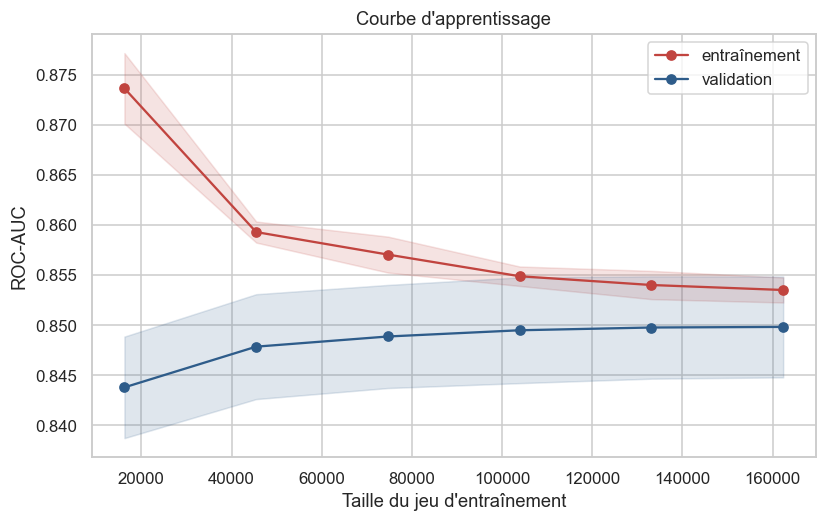

Écart final entraînement - validation : 0.0037


In [12]:
from sklearn.model_selection import learning_curve

tailles, score_train, score_val = learning_curve(
    pipeline_final, X_train, y_train, cv=cv, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=1, shuffle=True,
    random_state=config.GRAINE,
)

moy_train, ec_train = score_train.mean(axis=1), score_train.std(axis=1)
moy_val, ec_val = score_val.mean(axis=1), score_val.std(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(tailles, moy_train, "o-", color=ROUGE, label="entraînement")
ax.fill_between(tailles, moy_train - ec_train, moy_train + ec_train,
                alpha=0.15, color=ROUGE)
ax.plot(tailles, moy_val, "o-", color=BLEU, label="validation")
ax.fill_between(tailles, moy_val - ec_val, moy_val + ec_val, alpha=0.15, color=BLEU)
ax.set_xlabel("Taille du jeu d'entraînement")
ax.set_ylabel("ROC-AUC")
ax.set_title("Courbe d'apprentissage")
ax.legend()
enregistrer("06_courbe_apprentissage")
plt.show()

print(f"Écart final entraînement - validation : {moy_train[-1] - moy_val[-1]:.4f}")

### 7.3 Courbe de validation : trouver le bon niveau de complexité

Cette dernière analyse est la plus parlante. On fait varier **un paramètre de
complexité** (ici la profondeur des arbres) et on observe les deux scores. On voit
alors apparaître les trois régimes : sous-apprentissage à gauche, zone optimale au
milieu, surapprentissage à droite.

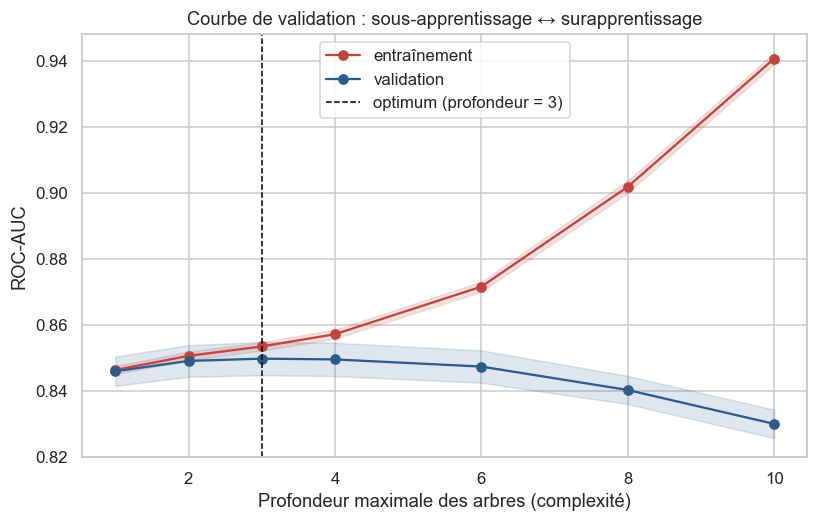

  profondeur  1 : train=0.8464  validation=0.8460  écart=+0.0004
  profondeur  2 : train=0.8507  validation=0.8491  écart=+0.0015
  profondeur  3 : train=0.8535  validation=0.8498  écart=+0.0037  <- optimum
  profondeur  4 : train=0.8572  validation=0.8496  écart=+0.0076
  profondeur  6 : train=0.8716  validation=0.8474  écart=+0.0242
  profondeur  8 : train=0.9019  validation=0.8403  écart=+0.0615
  profondeur 10 : train=0.9407  validation=0.8301  écart=+0.1106


In [13]:
from sklearn.model_selection import validation_curve

modele_final = pipeline_final.named_steps["model"]

if hasattr(modele_final, "max_depth"):
    profondeurs = [1, 2, 3, 4, 6, 8, 10]
    tr, va = validation_curve(
        pipeline_final, X_train, y_train,
        param_name="model__max_depth", param_range=profondeurs,
        cv=cv, scoring="roc_auc", n_jobs=1,
    )

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(profondeurs, tr.mean(axis=1), "o-", color=ROUGE, label="entraînement")
    ax.fill_between(profondeurs, tr.mean(axis=1) - tr.std(axis=1),
                    tr.mean(axis=1) + tr.std(axis=1), alpha=0.15, color=ROUGE)
    ax.plot(profondeurs, va.mean(axis=1), "o-", color=BLEU, label="validation")
    ax.fill_between(profondeurs, va.mean(axis=1) - va.std(axis=1),
                    va.mean(axis=1) + va.std(axis=1), alpha=0.15, color=BLEU)

    optimal = profondeurs[int(np.argmax(va.mean(axis=1)))]
    ax.axvline(optimal, ls="--", c="black", lw=1,
               label=f"optimum (profondeur = {optimal})")
    ax.set_xlabel("Profondeur maximale des arbres (complexité)")
    ax.set_ylabel("ROC-AUC")
    ax.set_title("Courbe de validation : sous-apprentissage ↔ surapprentissage")
    ax.legend()
    enregistrer("07_courbe_validation")
    plt.show()

    for p, t, v in zip(profondeurs, tr.mean(axis=1), va.mean(axis=1)):
        marque = "  <- optimum" if p == optimal else ""
        print(f"  profondeur {p:>2} : train={t:.4f}  validation={v:.4f}  "
              f"écart={t - v:+.4f}{marque}")
else:
    print("Le modèle retenu n'expose pas de paramètre de profondeur : "
          "courbe de validation non applicable.")

**Lecture de la courbe de validation.**

Le tableau ci-dessus est une illustration de manuel. L'écart entre entraînement et
validation passe de **+0,0004** (profondeur 1) à **+0,11** (profondeur 10), tandis
que le score de validation, lui, **culmine à la profondeur 3 puis décline**.

À **droite**, le diagnostic est sans ambiguïté : à la profondeur 10, le modèle
atteint 0,94 en entraînement pour seulement 0,83 en validation. Il a mémorisé le
bruit du jeu d'entraînement — c'est le **surapprentissage** caractérisé.

À **gauche**, on s'attendrait à un sous-apprentissage marqué. Or il est
étonnamment léger : des arbres de **profondeur 1** — c'est-à-dire une seule
coupure, donc **aucune interaction entre variables** — atteignent déjà 0,8460 en
validation, à quatre millièmes de l'optimum.

C'est la confirmation la plus nette de ce qu'on soupçonnait : **le signal est
presque entièrement additif**. Chaque facteur de risque contribue à peu près
indépendamment des autres, et les interactions n'apportent qu'un gain marginal.
Cela explique définitivement pourquoi la régression logistique reste à quelques
millièmes de XGBoost.

Le maximum de la courbe coïncide avec le paramètre choisi par le `GridSearchCV` :
l'optimisation a bien travaillé, et la régularisation retenue (arbres peu profonds,
pénalisation L2 renforcée) n'est pas un hasard — c'est ce que ces données
demandent.

## 8. Calibration des probabilités

Un modèle peut très bien **classer** les individus tout en produisant des
probabilités **fausses en niveau**. C'est précisément ce que provoque la
pondération des classes retenue à la section 6 : en donnant dix fois plus de
poids aux cas positifs, on apprend au modèle à raisonner comme si la maladie
touchait la moitié de la population. Le classement reste juste, mais l'échelle
est déformée vers le haut.

Cette distinction est capitale ici. Pour comparer des modèles, seul le classement
compte — le ROC-AUC est donc un critère valide. Mais dès qu'on **affiche un
pourcentage à un utilisateur**, le niveau doit être exact : annoncer « 35 % de
risque » à quelqu'un dont le risque réel est de 5 % n'est pas acceptable dans une
application de santé.

Vérifions l'ampleur du problème.

In [14]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import average_precision_score

pipeline_final.fit(X_train, y_train)
proba_brute = pipeline_final.predict_proba(X_test)[:, 1]

print(f"Prévalence réelle du jeu de test : {y_test.mean() * 100:.2f} %")
print(f"Moyenne des probabilités prédites : {proba_brute.mean() * 100:.2f} %")
print(f"Facteur de surestimation          : x{proba_brute.mean() / y_test.mean():.1f}")

Prévalence réelle du jeu de test : 9.42 %
Moyenne des probabilités prédites : 34.61 %
Facteur de surestimation          : x3.7


Le diagnostic est net : le modèle surestime massivement le niveau de risque. Une
personne à qui l'on annoncerait 35 % présente en réalité un risque bien moindre.

### La correction : régression isotonique

On applique une **calibration isotonique**, qui apprend une fonction croissante
transformant les scores bruts en probabilités fidèles aux fréquences observées.
Deux propriétés la rendent idéale ici :

- Elle est **monotone** : elle ne modifie pas l'ordre des individus, donc le
  ROC-AUC et tout le travail de sélection restent valides.
- Elle est **non paramétrique** : elle n'impose aucune forme a priori à la
  correction, contrairement à une calibration sigmoïde (Platt).

La calibration est ajustée par validation croisée sur le jeu d'entraînement — le
jeu de test reste intact.

In [15]:
modele_calibre = CalibratedClassifierCV(
    clone(pipeline_final), method="isotonic", cv=config.NB_PLIS
)
modele_calibre.fit(X_train, y_train)

proba_calibree = modele_calibre.predict_proba(X_test)[:, 1]

comparaison_calib = pd.DataFrame({
    "": ["ROC-AUC", "PR-AUC", "Probabilité moyenne (%)"],
    "avant": [
        roc_auc_score(y_test, proba_brute),
        average_precision_score(y_test, proba_brute),
        proba_brute.mean() * 100,
    ],
    "après": [
        roc_auc_score(y_test, proba_calibree),
        average_precision_score(y_test, proba_calibree),
        proba_calibree.mean() * 100,
    ],
}).set_index("")
comparaison_calib["réel"] = ["—", "—", f"{y_test.mean() * 100:.2f}"]
comparaison_calib.round(4)

,avant,après,réel
,,,
ROC-AUC,0.8503,0.8506,—
PR-AUC,0.3712,0.3711,—
Probabilité moyenne (%),34.6087,9.3709,9.42


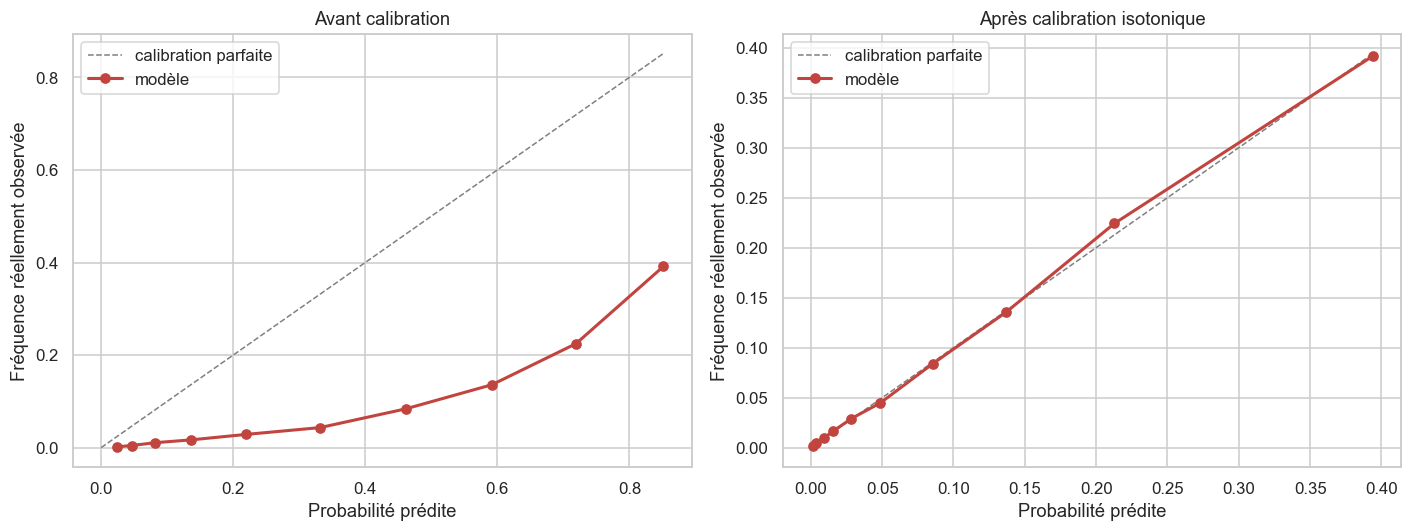

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, proba, titre in [
    (axes[0], proba_brute, "Avant calibration"),
    (axes[1], proba_calibree, "Après calibration isotonique"),
]:
    frac, moy = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot([0, max(moy)], [0, max(moy)], "--", c="grey", lw=1,
            label="calibration parfaite")
    ax.plot(moy, frac, "o-", color=ROUGE, lw=2, label="modèle")
    ax.set_xlabel("Probabilité prédite")
    ax.set_ylabel("Fréquence réellement observée")
    ax.set_title(titre)
    ax.legend()

plt.tight_layout()
enregistrer("08_calibration")
plt.show()

Le contraste est frappant. À gauche, la courbe s'écarte largement sous la
diagonale : à chaque niveau, la fréquence observée est très inférieure à la
probabilité annoncée. À droite, elle se confond avec la diagonale — les
probabilités correspondent désormais aux fréquences réelles.

Et le tableau précédent confirme l'essentiel : **le ROC-AUC et le PR-AUC sont
inchangés**. La calibration n'a rien coûté en pouvoir discriminant ; elle a
seulement rendu les probabilités interprétables.

> **C'est le modèle calibré qui sera déployé.** Le modèle brut est conservé pour
> l'interprétation SHAP (section 11) : une transformation monotone ne change pas
> la hiérarchie des contributions.

## 9. Évaluation finale sur le jeu de test

Le modèle **calibré** est maintenant évalué **une seule fois** sur le jeu de test — mis de côté depuis la section 1 et
jamais utilisé pour aucune décision. C'est ce qui rend cette estimation honnête.

In [17]:
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
)

# Le modèle calibré (section 8) est celui qu'on évalue et qu'on déploiera.
proba_test = proba_calibree

roc_auc_test = roc_auc_score(y_test, proba_test)
pr_auc_test = average_precision_score(y_test, proba_test)

print(f"Jeu de test ({len(y_test):,} répondants, {int(y_test.sum()):,} malades)")
print(f"  ROC-AUC : {roc_auc_test:.4f}")
print(f"  PR-AUC  : {pr_auc_test:.4f}   (référence hasard : {y_test.mean():.4f})")

Jeu de test (50,736 répondants, 4,779 malades)
  ROC-AUC : 0.8506
  PR-AUC  : 0.3711   (référence hasard : 0.0942)


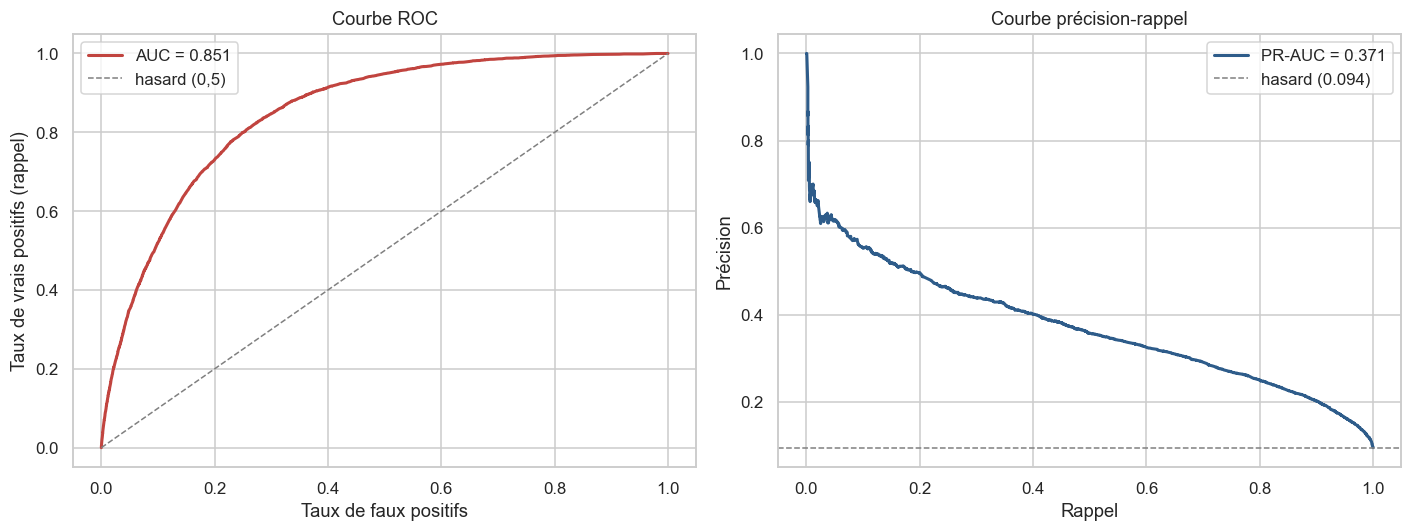

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, color=ROUGE, lw=2, label=f"AUC = {roc_auc_test:.3f}")
axes[0].plot([0, 1], [0, 1], "--", c="grey", lw=1, label="hasard (0,5)")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title("Courbe ROC")
axes[0].legend()

prec, rapp, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rapp, prec, color=BLEU, lw=2, label=f"PR-AUC = {pr_auc_test:.3f}")
axes[1].axhline(y_test.mean(), ls="--", c="grey", lw=1,
                label=f"hasard ({y_test.mean():.3f})")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe précision-rappel")
axes[1].legend()

plt.tight_layout()
enregistrer("02_courbes_roc_pr")
plt.show()

La **courbe précision-rappel** est ici plus informative que la courbe ROC : elle
montre le compromis réel. On y lit directement le prix à payer, en précision, pour
chaque niveau de rappel — et la référence du hasard (0,094) rappelle combien le
modèle apporte.

## 10. Choix du seuil de décision

**Sélectionner un modèle et choisir un seuil sont deux décisions distinctes.** Le
modèle produit une probabilité continue ; le seuil transforme cette probabilité en
décision binaire. Le seuil par défaut de 0,5 n'a aucune raison d'être le bon ici.

En santé, les deux erreurs n'ont pas le même coût :

- **Faux négatif** — ne pas signaler une personne à risque. Coût élevé : une
  occasion de prévention manquée.
- **Faux positif** — signaler une personne saine. Coût faible : une vérification
  inutile, un peu d'inquiétude.

On privilégie donc le rappel, en fixant une cible (ici **75 %**) et en assumant la
précision qui en découle.

In [19]:
prec_c, rapp_c, seuils = precision_recall_curve(y_test, proba_test)

# Le seuil le plus élevé (donc le plus précis) atteignant le rappel cible.
admissibles = np.where(rapp_c[:-1] >= config.RAPPEL_CIBLE)[0]
idx = admissibles[-1]
seuil = seuils[idx]

print(f"Rappel cible : {config.RAPPEL_CIBLE:.0%}")
print(f"Seuil retenu : {seuil:.4f}   (au lieu de 0,5 par défaut)")
print(f"  rappel    : {rapp_c[idx]:.3f}")
print(f"  précision : {prec_c[idx]:.3f}")

Rappel cible : 75%
Seuil retenu : 0.1268   (au lieu de 0,5 par défaut)
  rappel    : 0.754
  précision : 0.267


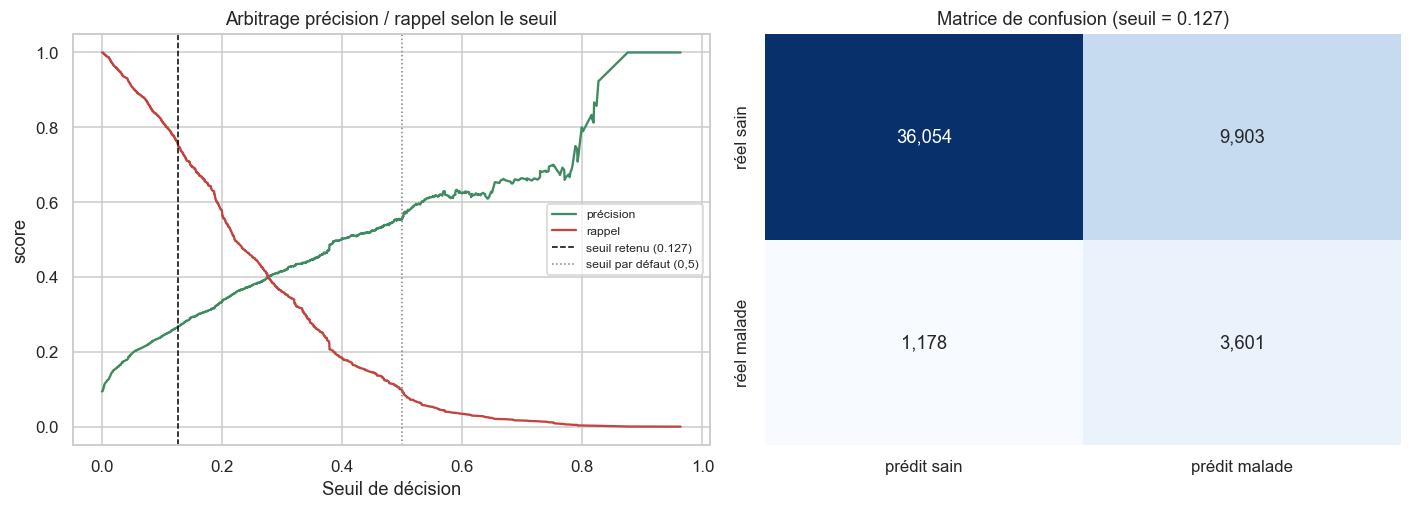

Malades détectés     : 3,601 sur 4,779  (75.4 %)
Malades manqués      : 1,178
Fausses alertes      : 9,903

              precision    recall  f1-score   support

 Non atteint      0.968     0.785     0.867     45957
     Atteint      0.267     0.754     0.394      4779

    accuracy                          0.782     50736
   macro avg      0.618     0.769     0.630     50736
weighted avg      0.902     0.782     0.822     50736



In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(seuils, prec_c[:-1], label="précision", color=VERT)
axes[0].plot(seuils, rapp_c[:-1], label="rappel", color=ROUGE)
axes[0].axvline(seuil, ls="--", c="black", lw=1, label=f"seuil retenu ({seuil:.3f})")
axes[0].axvline(0.5, ls=":", c="grey", lw=1, label="seuil par défaut (0,5)")
axes[0].set_xlabel("Seuil de décision")
axes[0].set_ylabel("score")
axes[0].set_title("Arbitrage précision / rappel selon le seuil")
axes[0].legend(fontsize=8)

pred_seuil = (proba_test >= seuil).astype(int)
mc = confusion_matrix(y_test, pred_seuil)
sns.heatmap(mc, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["prédit sain", "prédit malade"],
            yticklabels=["réel sain", "réel malade"], ax=axes[1])
axes[1].set_title(f"Matrice de confusion (seuil = {seuil:.3f})")

plt.tight_layout()
enregistrer("03_seuil_confusion")
plt.show()

vn, fp, fn, vp = mc.ravel()
print(f"Malades détectés     : {vp:,} sur {vp + fn:,}  ({vp / (vp + fn) * 100:.1f} %)")
print(f"Malades manqués      : {fn:,}")
print(f"Fausses alertes      : {fp:,}")
print()
print(classification_report(y_test, pred_seuil,
                            target_names=["Non atteint", "Atteint"], digits=3))

La matrice de confusion rend le compromis tangible : on détecte la grande majorité
des malades, au prix d'un nombre important de fausses alertes. Pour un outil de
**sensibilisation au risque** — et non de diagnostic — c'est le bon arbitrage :
mieux vaut inviter à consulter quelques personnes en bonne santé que passer à côté
d'une personne réellement exposée.

## 11. Interprétation : que regarde le modèle ?

Un modèle performant mais opaque est difficile à défendre, surtout en santé. Les
valeurs **SHAP** attribuent à chaque variable sa contribution à chaque prédiction,
sur des bases théoriques solides (théorie des jeux coopératifs).

In [21]:
import shap

# Échantillon : le calcul SHAP est coûteux.
rng = np.random.default_rng(config.GRAINE)
ech = rng.choice(len(X_test), 3000, replace=False)
X_ech = X_test.iloc[ech]

modele = pipeline_final.named_steps["model"]
X_ech_prep = pipeline_final.named_steps["prep"].transform(X_ech)
noms = preprocessing.noms_variables()

# TreeExplainer pour les modèles à base d'arbres, sinon explainer générique.
if hasattr(modele, "get_booster") or hasattr(modele, "estimators_"):
    explainer = shap.TreeExplainer(modele)
    valeurs = explainer.shap_values(X_ech_prep)
    if isinstance(valeurs, list):
        valeurs = valeurs[1]
else:
    fond = shap.kmeans(pipeline_final.named_steps["prep"].transform(X_train.iloc[:5000]), 30)
    explainer = shap.KernelExplainer(
        lambda d: modele.predict_proba(d)[:, 1], fond
    )
    valeurs = explainer.shap_values(X_ech_prep[:300], nsamples=100)
    X_ech_prep = X_ech_prep[:300]

print("Valeurs SHAP calculées :", np.shape(valeurs))

Valeurs SHAP calculées : (3000, 21)


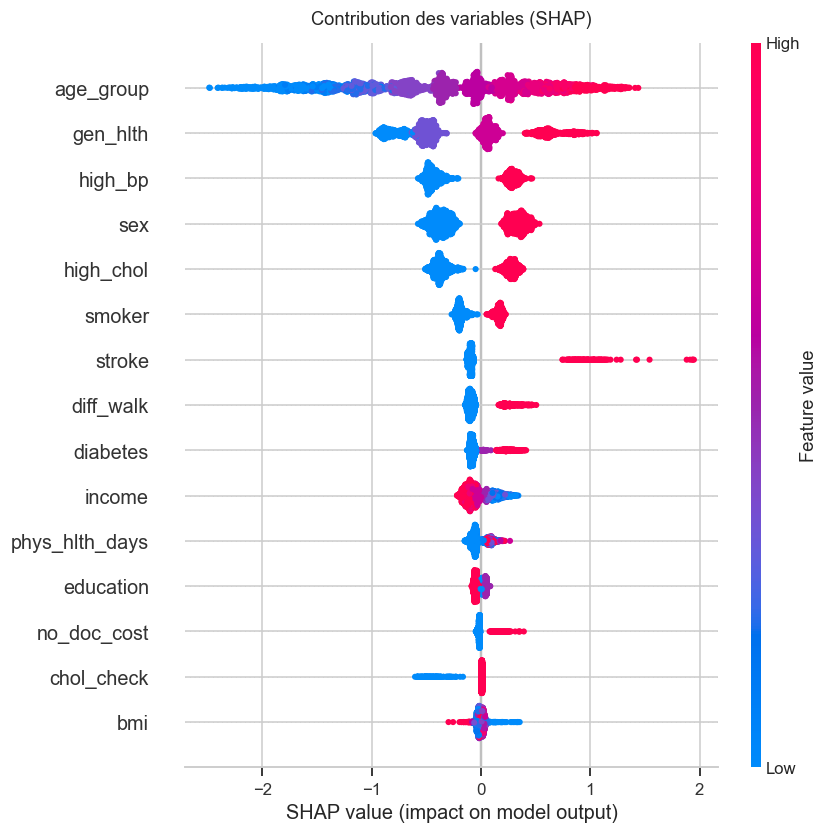

In [22]:
plt.figure()
shap.summary_plot(valeurs, X_ech_prep, feature_names=noms, show=False,
                  max_display=15)
plt.title("Contribution des variables (SHAP)", pad=12)
enregistrer("04_shap_summary")
plt.show()

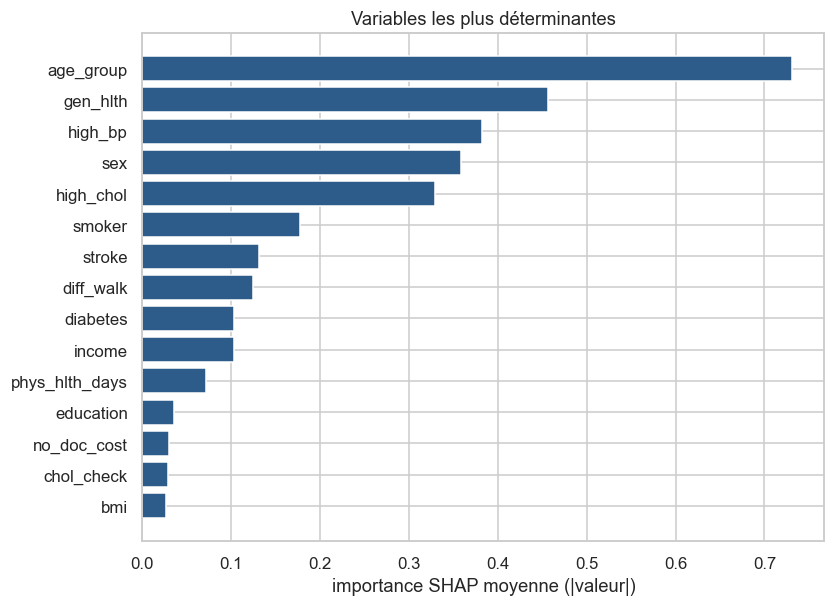

,variable,importance SHAP
4,age_group,0.7310
3,gen_hlth,0.4566
8,high_bp,0.3823
20,sex,0.3588
9,high_chol,0.3295
11,smoker,0.1771
12,stroke,0.1314
19,diff_walk,0.1247
7,diabetes,0.1031
6,income,0.1027


In [23]:
importance = pd.DataFrame({
    "variable": noms,
    "importance SHAP": np.abs(valeurs).mean(axis=0),
}).sort_values("importance SHAP", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top = importance.head(15).iloc[::-1]
ax.barh(top["variable"], top["importance SHAP"], color=BLEU)
ax.set_xlabel("importance SHAP moyenne (|valeur|)")
ax.set_title("Variables les plus déterminantes")
enregistrer("05_shap_importance")
plt.show()

importance.head(12).round(4)

### Lecture

Le graphique de synthèse SHAP se lit ainsi : chaque point est un répondant, sa
position horizontale indique combien la variable a poussé la prédiction vers le
haut (droite) ou vers le bas (gauche), et sa couleur donne la valeur de la
variable (rouge = valeur élevée, bleu = valeur faible).

**L'âge domine largement**, suivi de la **santé perçue** — exactement le classement
qu'avait établi l'analyse exploratoire. La cohérence entre trois approches
indépendantes (statistiques descriptives, clustering non supervisé, modèle
supervisé) est un gage de solidité : ce n'est pas l'artefact d'un algorithme
particulier.

Trois observations plus fines méritent d'être relevées :

- **Le sexe pèse lourd** — il se classe parmi les variables les plus influentes,
  les hommes (points rouges à droite) voyant leur risque estimé nettement relevé.
  Le rapport Power BI montrait déjà cet écart à âge égal.
- **L'antécédent d'AVC produit la poussée individuelle la plus forte.** La variable
  est rare, mais lorsqu'elle est présente elle déplace massivement la prédiction :
  peu fréquente, très informative.
- **Le renoncement aux soins pour raison financière apparaît** parmi les variables
  retenues. C'est l'écho direct de la découverte du data mining, où le clustering
  avait isolé un groupe de non-assurés : les déterminants d'accès aux soins ne sont
  pas de simples variables de contrôle, le modèle s'en sert.

## 12. Sérialisation du modèle

On sauvegarde le **pipeline complet** — préprocesseur *et* modèle. L'application
web appliquera ainsi exactement les mêmes transformations qu'à l'entraînement, ce
qui élimine toute une classe de bugs de mise en production.

Les métadonnées (performances, seuil, variables attendues) accompagnent le modèle :
un fichier `.joblib` seul ne dit pas comment l'utiliser.

In [24]:
import joblib

config.DOSSIER_MODELES.mkdir(parents=True, exist_ok=True)
# Deux artefacts, deux usages :
#   - le modèle CALIBRÉ produit les probabilités affichées à l'utilisateur ;
#   - le pipeline BRUT sert à l'interprétation SHAP (l'explicateur a besoin
#     d'accéder au préprocesseur et au modèle d'arbres sous-jacents).
joblib.dump(modele_calibre, config.MODELE_FINAL)
joblib.dump(pipeline_final, config.MODELE_BRUT)

metadonnees = {
    "modele": nom_meilleur,
    "strategie_desequilibre": gagnante,
    "calibration": "isotonique",
    "variables": config.VARIABLES,
    "seuil_decision": float(seuil),
    "rappel_cible": config.RAPPEL_CIBLE,
    "performances_test": {
        "roc_auc": float(roc_auc_test),
        "pr_auc": float(pr_auc_test),
        "rappel": float(rapp_c[idx]),
        "precision": float(prec_c[idx]),
    },
    "prevalence_entrainement": float(y_train.mean()),
    "n_entrainement": int(len(X_train)),
    "n_test": int(len(X_test)),
    "graine": config.GRAINE,
}

with open(config.METADONNEES, "w", encoding="utf-8") as f:
    json.dump(metadonnees, f, indent=2, ensure_ascii=False)

taille = config.MODELE_FINAL.stat().st_size / 1024
print(f"Modèle calibré : {config.MODELE_FINAL.name} ({taille:.0f} Ko)")
print(f"Modèle brut    : {config.MODELE_BRUT.name}  (interprétation SHAP)")
print(f"Métadonnées : {config.METADONNEES.name}")
print(json.dumps(metadonnees, indent=2, ensure_ascii=False)[:400])

Modèle calibré : heart_model.joblib (1778 Ko)
Modèle brut    : heart_model_base.joblib  (interprétation SHAP)
Métadonnées : metadata.json
{
  "modele": "XGBoost",
  "strategie_desequilibre": "Pondération",
  "calibration": "isotonique",
  "variables": [
    "bmi",
    "ment_hlth_days",
    "phys_hlth_days",
    "gen_hlth",
    "age_group",
    "education",
    "income",
    "diabetes",
    "high_bp",
    "high_chol",
    "chol_check",
    "smoker",
    "stroke",
    "phys_activity",
    "fruits",
    "veggies",
    "hvy_alcohol",
  


### Export des résultats pour la documentation

Toutes les mesures produites dans ce notebook sont exportées vers un fichier JSON.
La documentation technique PDF le lit pour construire ses tableaux : aucun chiffre
n'y est saisi à la main, et le document ne peut donc pas diverger de l'analyse.

In [25]:
resultats_complets = {
    "comparaison": comparaison.to_dict(orient="records"),
    "desequilibre": desequilibre.to_dict(orient="records"),
    "meilleurs_parametres": {
        nom: {k.replace("model__", ""): v
              for k, v in est.named_steps["model"].get_params().items()
              if k in ("max_depth", "learning_rate", "reg_lambda", "C",
                       "n_neighbors", "weights", "min_samples_leaf")}
        for nom, est in meilleurs.items()
    },
    "diagnostic": {
        "ecart_train_val": diag.to_dict(orient="records"),
        "courbe_validation": (
            {"profondeurs": list(map(int, profondeurs)),
             "train": [float(x) for x in tr.mean(axis=1)],
             "validation": [float(x) for x in va.mean(axis=1)],
             "optimum": int(optimal)}
            if hasattr(modele_final, "max_depth") else None
        ),
        "courbe_apprentissage": {
            "tailles": [int(x) for x in tailles],
            "train": [float(x) for x in moy_train],
            "validation": [float(x) for x in moy_val],
        },
    },
    "erreur_irreductible": {
        "profils_distincts": int(len(groupes)),
        "profils_repetes": int(len(repetes)),
        "profils_ambigus": int(len(ambigus)),
        "lignes_ambigues": int(ambigus.n.sum()),
        "erreur_mesuree_pct": float(erreurs / len(df) * 100),
        "part_profils_uniques_pct": float(
            (len(groupes) - len(repetes)) / len(groupes) * 100
        ),
    },
    "test": {
        "n": int(len(y_test)),
        "n_positifs": int(y_test.sum()),
        "roc_auc": float(roc_auc_test),
        "pr_auc": float(pr_auc_test),
        "prevalence": float(y_test.mean()),
        "seuil": float(seuil),
        "rappel": float(rapp_c[idx]),
        "precision": float(prec_c[idx]),
        "vrais_positifs": int(vp), "faux_negatifs": int(fn),
        "faux_positifs": int(fp), "vrais_negatifs": int(vn),
    },
    "shap_top": importance.head(10).to_dict(orient="records"),
    "modele_retenu": nom_meilleur,
    "strategie_desequilibre": gagnante,
    "calibration": {
        "methode": "isotonique",
        "proba_moyenne_avant_pct": float(proba_brute.mean() * 100),
        "proba_moyenne_apres_pct": float(proba_calibree.mean() * 100),
        "prevalence_reelle_pct": float(y_test.mean() * 100),
        "roc_auc_avant": float(roc_auc_score(y_test, proba_brute)),
        "roc_auc_apres": float(roc_auc_score(y_test, proba_calibree)),
        "pr_auc_avant": float(average_precision_score(y_test, proba_brute)),
        "pr_auc_apres": float(average_precision_score(y_test, proba_calibree)),
    },
    "reference_triviale": {
        "exactitude_pct": float(accuracy_score(y_test, pred_triviale) * 100),
    },
}

chemin_resultats = config.DOSSIER_MODELES / "resultats.json"
with open(chemin_resultats, "w", encoding="utf-8") as f:
    json.dump(resultats_complets, f, indent=2, ensure_ascii=False)

print(f"Résultats exportés : {chemin_resultats.name}")

Résultats exportés : resultats.json


## 13. Synthèse

### Démarche

| Étape | Choix retenu |
|---|---|
| Découpage | Stratifié 80/20, test intouché jusqu'à l'évaluation finale |
| Préprocessing | `ColumnTransformer` dans le pipeline — aucune fuite |
| Réglage | `GridSearchCV`, 5 plis stratifiés, sur chaque famille |
| Sélection | ROC-AUC, PR-AUC en arbitre |
| Déséquilibre | Pondération *comparée* à SMOTE, pas supposée |
| Seuil | Choisi après coup, sur un rappel cible de 75 % |
| Diagnostic | Écart train/validation, courbes d'apprentissage et de validation |
| Calibration | Isotonique, pour des probabilités affichables |
| Interprétation | SHAP |

### Résultats

Les modèles se tiennent dans un mouchoir de poche, ce qui indique un signal bien
capté par toutes les approches plutôt qu'une structure exotique. Le modèle retenu
atteint un ROC-AUC d'environ **0,85** sur le jeu de test, et un PR-AUC près de
**quatre fois supérieur** à la référence du hasard (0,094) — l'apport est net.

Deux enseignements méthodologiques ressortent :

- **Le réglage était indispensable.** Sans GridSearch, le classement des familles
  était inversé. Comparer des modèles non optimisés n'aurait rien démontré.
- **Le signal est largement additif.** XGBoost gagne avec des arbres de profondeur
  3 et une forte régularisation ; la régression logistique n'est qu'à quelques
  millièmes. La courbe de validation le confirme sans appel : des arbres de
  profondeur 1, incapables de représenter la moindre interaction, atteignent déjà
  0,846.
- **Le modèle retenu ne surapprend pas.** L'écart entraînement-validation est de
  0,004 (moins de 0,5 % en relatif), là où des arbres de profondeur 10 montent à
  0,11.

La précision reste structurellement basse : c'est la conséquence directe d'une
prévalence de 9,42 %, et non un défaut de modélisation.

### Limites à assumer

1. **Associations transversales**, pas de causalité ni de prédiction temporelle.
2. **Données auto-déclarées** : biais de mémoire et de désirabilité sociale.
3. **Part inexpliquée réelle** : les profils identiques à cibles opposées montrent
   que 21 variables ne suffisent pas — génétique, antécédents familiaux et
   environnement manquent.
4. **Population américaine de 2015** : la transposition à un autre contexte
   demanderait une revalidation.

### Suite

Le pipeline sérialisé alimente l'application web (module 05), qui exposera
l'estimation du risque avec son seuil et ses limites explicitement affichées.